In [18]:
# CELL 1: Setup, Imports & Data Loading

# --- Core Libraries & Setup ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, average_precision_score, balanced_accuracy_score, matthews_corrcoef, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from scipy.stats import chi2_contingency
from tab_transformer_pytorch import TabTransformer
from pathlib import Path
import copy
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
import random
random.seed(SEED); np.random.seed(SEED)
try:
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

# --- Global Settings ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 8)})

# --- Load Data (NEW 80/20 SPLIT) ---
train_df = pd.read_csv('GSE164641_train_80.csv', index_col=0)
test_df = pd.read_csv('GSE164641_test_20.csv', index_col=0)

y_train_full = train_df['target'].map({'High': 1, 'Average': 0})
X_train_full = train_df.drop(columns=['target'])

y_test_holdout = test_df['target'].map({'High': 1, 'Average': 0})
X_test_holdout = test_df.drop(columns=['target'])
print("80% Train and 20% Hold-out Test data loaded successfully.")

80% Train and 20% Hold-out Test data loaded successfully.


In [24]:
# CELL 2: Define All Helper Functions

def process_fold_features(X_train, y_train, X_test):
    """Encapsulates all feature engineering for a single fold."""
    # (This function is a condensed version of our previous feature engineering cell)
    known_cat_cols = ['age', 'age_of_menarche', 'menopausal_status', 'brca1', 'brca2', 'blood_relatives_cancer', 'race',
                      'hispanic', 'bmi', 'ever_pregnant', 'tyrer_cuzick_score']
    cat_cols = [col for col in known_cat_cols if col in X_train.columns]
    X_train_cat = X_train[cat_cols].copy();
    X_test_cat = X_test[cat_cols].copy()
    if 'tyrer_cuzick_score' in X_train_cat.columns:
        for df in [X_train_cat, X_test_cat]: df.drop(columns=['tyrer_cuzick_score'], inplace=True)

    def clean_numeric_cols(df):
        for col in ['age', 'age_of_menarche', 'bmi']:
            if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
        return df

    X_train_cat = clean_numeric_cols(X_train_cat);
    X_test_cat = clean_numeric_cols(X_test_cat)
    imputation_values = {
        col: X_train_cat[col].median() if pd.api.types.is_numeric_dtype(X_train_cat[col]) else X_train_cat[col].mode()[
            0] for col in X_train_cat.columns}
    for col, value in imputation_values.items():
        X_train_cat[col] = X_train_cat[col].fillna(value)
        X_test_cat[col] = X_test_cat[col].fillna(value)
    bmi_bins = [0, 18.5, 25, 30, float('inf')];
    bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
    _, menarche_bins = pd.qcut(X_train_cat['age_of_menarche'], q=3, retbins=True, duplicates='drop');
    menarche_labels = ['Early', 'Normal', 'Late']
    if len(menarche_bins) - 1 != len(menarche_labels): menarche_labels = [f'g{k + 1}' for k in
                                                                          range(len(menarche_bins) - 1)]

    _, age_bins = pd.qcut(X_train_cat['age'], q=5, retbins=True, duplicates='drop')
    age_labels = [f'a{k + 1}' for k in range(len(age_bins) - 1)]

    for df in [X_train_cat, X_test_cat]:
        df['age_category'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, include_lowest=True)
        df['bmi_category'] = pd.cut(df['bmi'], bins=bmi_bins, labels=bmi_labels, right=False)
        df['menarche_category'] = pd.cut(df['age_of_menarche'], bins=menarche_bins, labels=menarche_labels,
                                         include_lowest=True)
        df.drop(columns=['age', 'bmi', 'age_of_menarche'], inplace=True)
    # selected_categorical_features = [col for col in X_train_cat.columns if chi2_contingency(pd.crosstab(X_train_cat[col].astype('category'), y_train))[1] < 0.05]
    candidate_for_chi2 = [c for c in X_train_cat.columns if c.endswith('_category') or c in
                          ['menopausal_status', 'brca1', 'brca2', 'blood_relatives_cancer', 'race', 'hispanic',
                           'ever_pregnant']]
    selected_categorical_features = [
        col for col in candidate_for_chi2
        if chi2_contingency(pd.crosstab(X_train_cat[col].astype('category'), y_train))[1] < 0.05
    ]

    gene_cols = X_train.columns.drop(cat_cols)
    X_train_cont_raw = X_train[gene_cols].copy();
    X_test_cont_raw = X_test[gene_cols].copy()
    X_train_cont_raw = X_train_cont_raw.T.groupby(level=0).sum().T
    all_gene_columns = X_train_cont_raw.columns
    X_test_cont_raw = X_test_cont_raw.T.groupby(level=0).sum().T.reindex(columns=all_gene_columns, fill_value=0)

    samples_df = pd.DataFrame({'condition': y_train})
    dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design='~condition');
    dds.deseq2()
    stat_res = DeseqStats(dds, contrast=['condition', 1, 0]);
    stat_res.summary();
    results_df = stat_res.results_df
    significant_genes = results_df[
        (results_df['padj'] < 0.05) & (abs(results_df['log2FoldChange']) > 1.0)].index.tolist()

    return X_train_cat, X_test_cat, selected_categorical_features, X_train_cont_raw, X_test_cont_raw, significant_genes

# [Revision]
def train_tt_in_cv(X_cat_train, X_cont_train, y_train, X_cat_test, X_cont_test, cat_cardinalities, fold_name=""):
    """
    A robust training function for Tab-Transformer inside a CV loop,
    featuring Early Stopping, Validation Split, and Parameter Counting.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # --- 1. Split 10% Validation Set for Early Stopping ---
    indices = np.arange(len(y_train))
    try:
        train_idx, val_idx = train_test_split(indices, test_size=0.1, stratify=y_train.values, random_state=42)
    except ValueError:
        # Fallback if specific classes are too small for stratification
        train_idx, val_idx = train_test_split(indices, test_size=0.1, random_state=42)
        
    y_train_full = y_train.values
    y_tr = torch.tensor(y_train_full[train_idx], dtype=torch.long).to(device)
    y_val = torch.tensor(y_train_full[val_idx], dtype=torch.long).to(device)
    
    # Safely handle potentially empty tensors
    X_cat_tr = X_cat_train[train_idx].to(device) if X_cat_train.shape[1] > 0 else torch.empty(len(train_idx), 0, dtype=torch.long).to(device)
    X_cat_val = X_cat_train[val_idx].to(device) if X_cat_train.shape[1] > 0 else torch.empty(len(val_idx), 0, dtype=torch.long).to(device)
    
    X_cont_tr = X_cont_train[train_idx].to(device) if X_cont_train.shape[1] > 0 else torch.empty(len(train_idx), 0).to(device)
    X_cont_val = X_cont_train[val_idx].to(device) if X_cont_train.shape[1] > 0 else torch.empty(len(val_idx), 0).to(device)

    # --- 2. Model Initialization & Parameter Counting ---
    model = TabTransformer(
        categories=cat_cardinalities,
        num_continuous=X_cont_train.shape[1],
        dim=32, dim_out=2, depth=6, heads=8
    ).to(device)

    if fold_name == "Final":
        num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  [TabTransformer] Trainable Parameters: {num_params}")

    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    
    # Dynamically compute class weights based on the training split
    pos = float((y_train_full[train_idx] == 1).sum())
    neg = float((y_train_full[train_idx] == 0).sum())
    w = torch.tensor([0.5, 0.5], dtype=torch.float32) if pos == 0 or neg == 0 else torch.tensor([neg/(pos+neg), pos/(pos+neg)], dtype=torch.float32)
    criterion = nn.CrossEntropyLoss(weight=w.to(device))
    
    # --- 3. Training Loop with Early Stopping ---
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []

    # Early stop
    for epoch in range(100): 
        model.train()
        optimizer.zero_grad()
        output = model(X_cat_tr, X_cont_tr)
        loss = criterion(output, y_tr)
        loss.backward()
        optimizer.step()
        
        # Validation Phase
        model.eval()
        with torch.no_grad():
            val_output = model(X_cat_val, X_cont_val)
            val_loss = criterion(val_output, y_val).item()
            
        train_losses.append(loss.item())
        val_losses.append(val_loss)
        
        # Check Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            if fold_name == "Final":
                print(f"  [Early Stopping] Triggered at epoch {epoch+1}")
            break
            
    # --- 4. Restore Best Weights & Plot Curve ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    if fold_name == "Final":
        plt.figure(figsize=(8, 6))
        plt.plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2)
        plt.plot(val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2)
        plt.title('TabTransformer Training vs Validation Loss (Early Stopping)')
        plt.xlabel('Epochs')
        plt.ylabel('CrossEntropy Loss')
        plt.legend()
        sns.despine()
        curve_path = OUT_DIR / "GSE164641_tabtransformer_loss_curve.png"
        plt.savefig(curve_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"  [Plot] Saved Loss Curve to: {curve_path}")

    # --- 5. Evaluate on actual Hold-out / Test Set ---
    model.eval()
    with torch.no_grad():
        test_output = model(X_cat_test.to(device), X_cont_test.to(device))
        y_pred_proba = torch.softmax(test_output, dim=1).cpu().numpy()[:, 1]
        
    return y_pred_proba

def get_comprehensive_metrics(y_true, y_prob):
    """
    A unified evaluator returning 7 core metrics to satisfy stringent reviewer demands.
    """
    y_pred = (y_prob >= 0.5).astype(int)
    
    # 1. Base Metrics
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    cr = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro_f1 = cr['macro avg']['f1-score']
    
    # 2. Imbalance-Aware Metrics
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    # 3. Sensitivity & Specificity
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        sensitivity, specificity = 0.0, 0.0
        
    return {
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Macro F1': macro_f1,
        'Bal. Acc.': bal_acc,
        'MCC': mcc,
        'Sensitivity': sensitivity,
        'Specificity': specificity
    }

def get_bootstrap_ci(y_true, y_prob, metric_func, n_boot=1000, alpha=0.05):
    """
    Bootstrap resampling to estimate 95% CI for a given metric.
    Includes safeguards for extremely small/imbalanced datasets (e.g., GSE240671).
    """
    boot_scores = []
    y_true_arr = np.array(y_true)
    y_prob_arr = np.array(y_prob)
    
    for _ in range(n_boot):
        try:
            idx = resample(np.arange(len(y_true_arr)), stratify=y_true_arr)
            score = metric_func(y_true_arr[idx], y_prob_arr[idx])
            boot_scores.append(score)
        except ValueError:
            continue
            
    if len(boot_scores) == 0:
        return np.nan, np.nan, np.nan
        
    boot_scores = np.array(boot_scores)
    lower = np.percentile(boot_scores, 100 * (alpha / 2))
    upper = np.percentile(boot_scores, 100 * (1 - alpha / 2))
    return np.mean(boot_scores), lower, upper

print("Helper functions defined.")

Helper functions defined.


In [10]:
# CELL 3: The Main Cross-Validation Loop

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Create a dictionary to store results (AUC scores and TPRs for plotting)
results = {'AUCs': {}, 'TPRs': {}}
mean_fpr = np.linspace(0, 1, 100)  # Common x-axis for ROC curves
cr_macro = {}
cr_weighted = {}

# --- Start the Loop ---
for i, (train_index, test_index) in enumerate(skf.split(X_train_full, y_train_full)):
    print(f"\n========== FOLD {i + 1}/{N_SPLITS} ========== ")
    X_train, X_test = X_train_full.iloc[train_index], X_train_full.iloc[test_index]
    y_train, y_test = y_train_full.iloc[train_index], y_train_full.iloc[test_index]

    # --- 1. Perform feature engineering for the current fold ---
    X_train_cat, X_test_cat, sel_cat_feats, X_train_cont_raw, X_test_cont_raw, sig_genes = process_fold_features(
        X_train, y_train, X_test)

    if not sig_genes:  # correct1
        print(f"Fold {i + 1}: no significant genes; continuous stream will be empty this fold.")
        # print(f"Fold {i+1} skipped due to no significant genes found.")
        # continue

    # --- 2. Prepare final data subsets for this fold ---
    scaler = StandardScaler();
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
    X_train_cont_final = pd.DataFrame(scaler.fit_transform(np.log1p(X_train_cont_raw[sig_genes])), index=X_train.index,
                                      columns=sig_genes)
    X_test_cont_final = pd.DataFrame(scaler.transform(np.log1p(X_test_cont_raw[sig_genes])), index=X_test.index,
                                     columns=sig_genes)
    X_train_cat_final = pd.DataFrame(onehot.fit_transform(X_train_cat[sel_cat_feats]), index=X_train.index,
                                     columns=onehot.get_feature_names_out())
    X_test_cat_final = pd.DataFrame(onehot.transform(X_test_cat[sel_cat_feats]), index=X_test.index,
                                    columns=onehot.get_feature_names_out())
    X_train_comb = pd.concat([X_train_cat_final, X_train_cont_final], axis=1);
    X_test_comb = pd.concat([X_test_cat_final, X_test_cont_final], axis=1)

    # Tab-Transformer data
    ordinal = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1);
    ordinal.fit(X_train_cat[sel_cat_feats])
    X_train_cat_ord = torch.tensor(ordinal.transform(X_train_cat[sel_cat_feats]), dtype=torch.long)
    X_test_cat_ord = torch.tensor(ordinal.transform(X_test_cat[sel_cat_feats]), dtype=torch.long)
    cat_cards = [len(cats) for cats in ordinal.categories_]
    X_train_cont_tensor = torch.tensor(X_train_cont_final.values, dtype=torch.float32)
    X_test_cont_tensor = torch.tensor(X_test_cont_final.values, dtype=torch.float32)

    # --- 3. Run all experiments for this fold ---
    has_cont = (len(sig_genes) > 0)
    has_cat = (len(sel_cat_feats) > 0)

    models_to_run = {}
    if has_cont:
        models_to_run['TT_cont'] = lambda: train_tt_in_cv(
            torch.empty(len(X_train), 0, dtype=torch.long), X_train_cont_tensor, y_train,
            torch.empty(len(X_test), 0, dtype=torch.long), X_test_cont_tensor, [])
        
        models_to_run['RF_cont'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        models_to_run['LR_cont'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        models_to_run['LASSO_cont'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]

        # [NEW] XGBoost (gene only)
        models_to_run['XGB_cont'] = lambda: XGBClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42, 
            scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum()
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        # [NEW] LightGBM (gene only)
        models_to_run['LGBM_cont'] = lambda: LGBMClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, class_weight='balanced', verbose=-1
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]

        # [NEW] CatBoost (gene only)
        models_to_run['CB_cont'] = lambda: CatBoostClassifier(
            iterations=100, depth=5, learning_rate=0.05, random_seed=42, auto_class_weights='Balanced', verbose=False
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        
        # [NEW] MLP (gene only)
        models_to_run['MLP_cont'] = lambda: MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]

    if has_cat:
        models_to_run['TT_cat'] = lambda: train_tt_in_cv(
            X_train_cat_ord, torch.empty(len(X_train), 0), y_train, X_test_cat_ord, torch.empty(len(X_test), 0),
            cat_cards)

    if has_cat and has_cont:
        models_to_run['TT_comb'] = lambda: train_tt_in_cv(
            X_train_cat_ord if has_cat else torch.empty(len(X_train), 0, dtype=torch.long),
            X_train_cont_tensor if has_cont else torch.empty(len(X_train), 0),
            y_train,
            X_test_cat_ord if has_cat else torch.empty(len(X_test), 0, dtype=torch.long),
            X_test_cont_tensor if has_cont else torch.empty(len(X_test), 0),
            cat_cards if has_cat else []
        )
        models_to_run['RF_comb'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LR_comb'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LASSO_comb'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        
        # [NEW] XGBoost (combined)
        models_to_run['XGB_comb'] = lambda: XGBClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42, 
            scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum()
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        
        # [NEW] LightGBM (combined)
        models_to_run['LGBM_comb'] = lambda: LGBMClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, class_weight='balanced', verbose=-1
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]

        # [NEW] CatBoost (combined)
        models_to_run['CB_comb'] = lambda: CatBoostClassifier(
            iterations=100, depth=5, learning_rate=0.05, random_seed=42, auto_class_weights='Balanced', verbose=False
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        
        # [NEW] MLP (combined)
        models_to_run['MLP_comb'] = lambda: MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]

    for name, train_eval_func in models_to_run.items():
        if name not in results['AUCs']:  # Initialize lists on first fold
            results['AUCs'][name] = []
            results['TPRs'][name] = []

        y_proba = train_eval_func()
        auc_score = roc_auc_score(y_test, y_proba)
        results['AUCs'][name].append(auc_score)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        results['TPRs'][name].append(interp_tpr)
        print(f"  {name}: AUC = {auc_score:.4f}")
        y_pred = (y_proba >= 0.5).astype(int)
        cr = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        if name not in cr_macro:
            cr_macro[name] = []
        if name not in cr_weighted:
            cr_weighted[name] = []

        cr_macro[name].append([
            cr["macro avg"]["precision"],
            cr["macro avg"]["recall"],
            cr["macro avg"]["f1-score"],
        ])
        cr_weighted[name].append([
            cr["weighted avg"]["precision"],
            cr["weighted avg"]["recall"],
            cr["weighted avg"]["f1-score"],
        ])

print("\n========== CROSS-VALIDATION COMPLETE ==========")


========== FOLD 1/5 ========== 


Fitting size factors...
... done in 0.09 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.37 seconds.

Fitting dispersion trend curve...
... done in 0.44 seconds.

Fitting MAP dispersions...
... done in 1.69 seconds.

Fitting LFCs...
... done in 1.49 seconds.

Calculating cook's distance...
... done in 0.14 seconds.

Replacing 2020 outlier genes.

Fitting dispersions...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.17 seconds.

Fitting LFCs...
... done in 0.17 seconds.

Running Wald tests...
... done in 1.42 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         49.159208        0.071491  0.174453  0.409801  0.681952  0.848149
A1BG-AS1     93.343725        0.232047  0.155021  1.496874  0.134426  0.371911
A1CF          3.638631        0.280300  0.247410  1.132937  0.257241  0.522963
A2M       22201.793441       -0.275718  0.118709 -2.322647  0.020198  0.134151
A2M-AS1     897.356938       -0.293788  0.177795 -1.652397  0.098454  0.312903
...                ...             ...       ...       ...       ...       ...
ZYG11A       47.217201        0.460765  0.285516  1.613802  0.106570  0.327266
ZYG11B     1241.844022       -0.023717  0.079707 -0.297550  0.766047  0.893099
ZYX        1969.890912       -0.140373  0.092466 -1.518108  0.128987  0.363750
ZZEF1      1935.282471       -0.062109  0.092575 -0.670907  0.502280  0.733799
ZZZ3       1417.032465        0.215281  0.062898  3.422698  0.000620  0.0216

...

Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         48.702096        0.020142  0.176035  0.114418  0.908906  0.966381
A1BG-AS1     88.736883        0.166032  0.156242  1.062658  0.287937  0.587990
A1CF          3.386477       -0.010028  0.248945 -0.040282  0.967868  0.989391
A2M       22601.178092       -0.173396  0.108357 -1.600233  0.109547  0.374502
A2M-AS1     930.613246       -0.136115  0.174983 -0.777875  0.436643  0.711677
...                ...             ...       ...       ...       ...       ...
ZYG11A       43.862298        0.330753  0.261428  1.265178  0.205808  0.501730
ZYG11B     1269.908138       -0.002789  0.082812 -0.033676  0.973136  0.991455
ZYX        1976.761663       -0.127000  0.094924 -1.337904  0.180928  0.472497
ZZEF1      1942.974138       -0.056484  0.095536 -0.591228  0.554368  0.790588
ZZZ3       1414.133504        0.189145  0.064167  2.947684  0.003202  0.0710

Fitting size factors...
... done in 0.11 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.54 seconds.

Fitting dispersion trend curve...
... done in 0.44 seconds.

Fitting MAP dispersions...
... done in 1.69 seconds.

Fitting LFCs...
... done in 2.07 seconds.

Calculating cook's distance...
... done in 0.13 seconds.

Replacing 1029 outlier genes.

Fitting dispersions...
... done in 0.14 seconds.

Fitting MAP dispersions...
... done in 0.13 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Running Wald tests...
... done in 1.45 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         45.592466        0.182156  0.161930  1.124908  0.260628  0.521646
A1BG-AS1     85.860613        0.249298  0.142824  1.745488  0.080900  0.276924
A1CF          3.336331        0.192321  0.251967  0.763281  0.445296  0.684329
A2M       22568.435974       -0.205049  0.111773 -1.834514  0.066578  0.248628
A2M-AS1     883.036690       -0.036602  0.160844 -0.227561  0.819988  0.918362
...                ...             ...       ...       ...       ...       ...
ZYG11A       42.658742        0.532463  0.271695  1.959785  0.050021  0.213692
ZYG11B     1265.688636       -0.061972  0.077563 -0.798989  0.424297  0.668431
ZYX        1897.546975       -0.076033  0.085085 -0.893613  0.371529  0.624714
ZZEF1      1937.793488       -0.096491  0.069460 -1.389166  0.164782  0.407872
ZZZ3       1381.709790        0.175503  0.057542  3.049975  0.002289  0.0490

In [11]:
summary_data = []

# Loop through the dictionary of AUC scores from the CV results
for name, auc_list in results['AUCs'].items():
    # Calculate the mean and standard deviation for each experiment's list of AUCs
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)
    
    summary_data.append({
        'Experiment': name.replace("_", " ").title(), # Make the name prettier
        'Mean AUC': mean_auc,
        'Std Dev (±)': std_auc
    })

# Create and sort the DataFrame for better readability
summary_cv_df = pd.DataFrame(summary_data).set_index('Experiment').sort_values(by='Mean AUC', ascending=False)

print("\n--- Final Cross-Validation Performance Summary ---")
print("Metrics are reported as Mean ± Standard Deviation over 5 folds.")

# Display the styled table
display(summary_cv_df.style
    .format({'Mean AUC': '{:.3f}', 'Std Dev (±)': '{:.3f}'})
    .background_gradient(cmap='Greens', subset=['Mean AUC'])
    .bar(subset=['Std Dev (±)'], color='#d4edda', align='zero')
    .set_properties(**{'border': '1px solid #dee2e6', 'padding': '8px'})
    .set_table_styles([{'selector': 'thead th', 'props': [('background-color', '#f8f9fa'), ('border-bottom', '2px solid #dee2e6')]}])
)

summary_cv_path = OUT_DIR / "cv_auc_summary.csv"
summary_cv_df.to_csv(summary_cv_path, index=True)
print(f"Saved CV AUC summary to: {summary_cv_path}")


--- Final Cross-Validation Performance Summary ---
Metrics are reported as Mean ± Standard Deviation over 5 folds.


,Mean AUC,Std Dev (±)
Experiment,,
Cb Comb,0.893,0.053
Lgbm Comb,0.888,0.044
Tt Comb,0.885,0.058
Xgb Comb,0.872,0.044
Tt Cat,0.870,0.089
Rf Comb,0.843,0.054
Lasso Comb,0.805,0.059
Lr Comb,0.716,0.063
Lgbm Cont,0.624,0.043


Saved CV AUC summary to: output\cv_auc_summary.csv


In [12]:
def _cr_store_to_df(store: dict, label: str) -> pd.DataFrame:
    rows = []
    for name, arr in store.items():
        A = np.asarray(arr, dtype=float)  # shape (n_folds, 3)
        mu = A.mean(axis=0)
        sd = A.std(axis=0)
        rows.append([
            name,
            mu[0], sd[0],
            mu[1], sd[1],
            mu[2], sd[2],
        ])
    return pd.DataFrame(rows, columns=[
        "Model",
        f"{label} Precision (mean)", f"{label} Precision (std)",
        f"{label} Recall (mean)",    f"{label} Recall (std)",
        f"{label} F1 (mean)",        f"{label} F1 (std)",
    ]).sort_values("Model").reset_index(drop=True)

macro_df = _cr_store_to_df(cr_macro, "Macro")
weighted_df = _cr_store_to_df(cr_weighted, "Weighted")

print("\n--- Classification Report (Macro avg) — 5-fold mean ± std ---")
display(macro_df)
print("\n--- Classification Report (Weighted avg) — 5-fold mean ± std ---")
display(weighted_df)

macro_path = OUT_DIR / "cv_classification_report_macro.csv"
weighted_path = OUT_DIR / "cv_classification_report_weighted.csv"
macro_df.to_csv(macro_path, index=False)
weighted_df.to_csv(weighted_path, index=False)
print(f"Saved CR tables to:\n- {macro_path}\n- {weighted_path}")


--- Classification Report (Macro avg) — 5-fold mean ± std ---


,Model,Macro Precision (mean),Macro Precision (std),Macro Recall (mean),Macro Recall (std),Macro F1 (mean),Macro F1 (std)
0,CB_comb,0.869050,0.063695,0.877124,0.062295,0.870174,0.064692
1,CB_cont,0.569490,0.082463,0.558824,0.067284,0.553837,0.071858
2,LASSO_comb,0.765278,0.054485,0.762908,0.064685,0.761003,0.058813
3,LASSO_cont,0.553926,0.079990,0.553268,0.080214,0.547591,0.072426
4,LGBM_comb,0.861666,0.072954,0.863562,0.072882,0.861356,0.072517
5,LGBM_cont,0.569186,0.057832,0.560948,0.051907,0.556783,0.053797
6,LR_comb,0.640376,0.075577,0.634477,0.078716,0.631344,0.079217
7,LR_cont,0.546760,0.098575,0.548366,0.094861,0.540249,0.101099
8,MLP_comb,0.599895,0.058593,0.581699,0.057220,0.567946,0.065708
9,MLP_cont,0.532063,0.022501,0.531046,0.024142,0.518555,0.034214



--- Classification Report (Weighted avg) — 5-fold mean ± std ---


,Model,Weighted Precision (mean),Weighted Precision (std),Weighted Recall (mean),Weighted Recall (std),Weighted F1 (mean),Weighted F1 (std)
0,CB_comb,0.880232,0.059396,0.872874,0.064214,0.873749,0.063456
1,CB_cont,0.582805,0.076178,0.576782,0.082648,0.570107,0.077323
2,LASSO_comb,0.775259,0.057478,0.772414,0.051732,0.770933,0.053856
3,LASSO_cont,0.573534,0.080600,0.564598,0.065987,0.563157,0.065267
4,LGBM_comb,0.868960,0.069961,0.866207,0.069487,0.866398,0.069467
5,LGBM_cont,0.583248,0.055229,0.583218,0.063427,0.575525,0.057777
6,LR_comb,0.653243,0.073546,0.658161,0.062622,0.650066,0.070011
7,LR_cont,0.564507,0.092984,0.577931,0.085690,0.564366,0.092255
8,MLP_comb,0.612411,0.053458,0.611264,0.046340,0.591655,0.053828
9,MLP_cont,0.549976,0.022260,0.543678,0.038938,0.534107,0.040043


Saved CR tables to:
- output\cv_classification_report_macro.csv
- output\cv_classification_report_weighted.csv



--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (with Std Dev) ---
Saved figure to: output\cv_roc_only_continuous.png


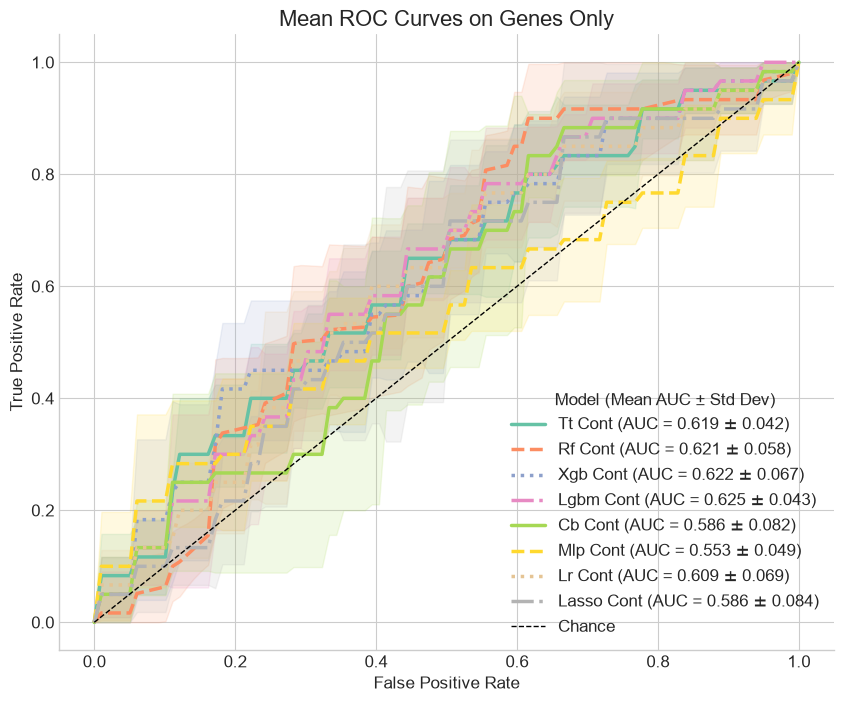


--- Generating Plot 2: Tab-Transformer Ablation Study (with Std Dev) ---
Saved figure to: output\cv_roc_tt_internal.png


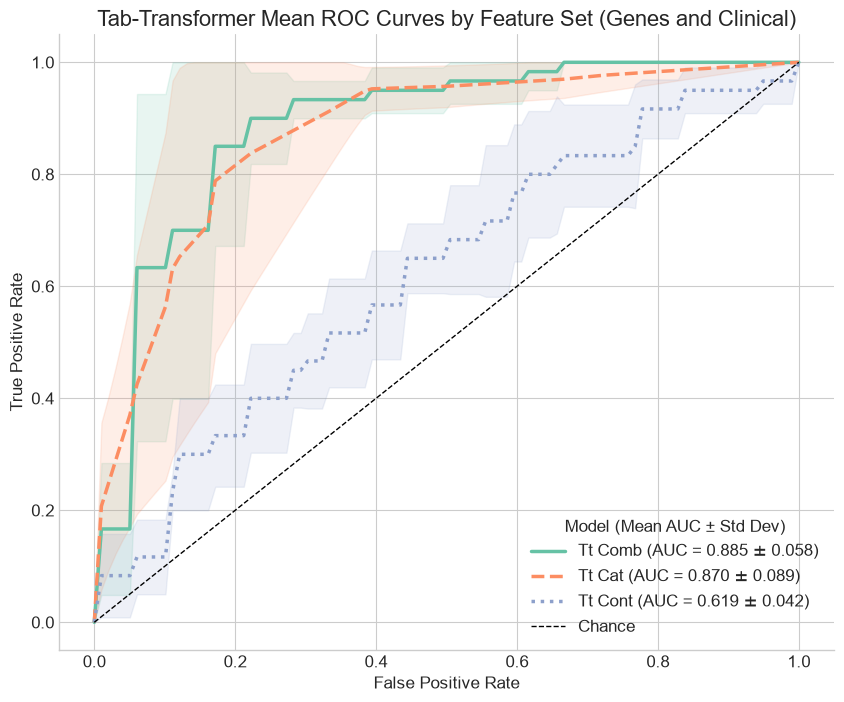


--- Generating Plot 3: Final Model Showdown on Combined Features (Genes and Clinical) (with Std Dev) ---
Saved figure to: output\cv_roc_combined.png


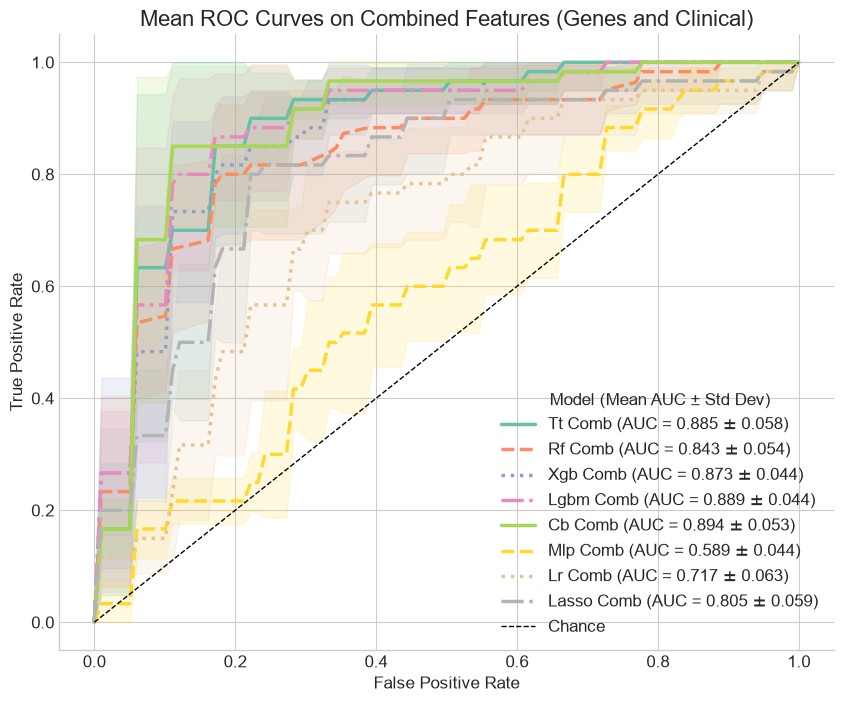

In [13]:
# CELL 5 (Revised): Generate Final Comparative Plots with Standard Deviation Bands

def plot_mean_roc_curves_with_std(results_tprs, results_aucs, model_keys, title, save_path=None):
    """
    Helper function to plot multiple mean ROC curves from CV results,
    including a shaded standard deviation band for each curve.
    """
    plt.figure(figsize=(10, 8))
    colors = sns.color_palette('Set2', n_colors=len(model_keys))
    linestyles = ['-', '--', ':', '-.']
    
    # --- Loop through each model to plot ---
    for i, key in enumerate(model_keys):
        # Check if results for this model exist
        if key not in results_tprs or not results_tprs[key]:
            print(f"Warning: No results found for '{key}'. Skipping this curve.")
            continue
            
        # --- Calculations for the current model ---
        tpr_array = np.array(results_tprs[key])
        mean_tprs = tpr_array.mean(axis=0)
        mean_tprs[-1] = 1.0 # Ensure the curve goes to the top-right corner
        
        # Calculate mean AUC and std of AUCs
        mean_auc = auc(mean_fpr, mean_tprs)
        std_auc = np.std(results_aucs[key])
        
        # Calculate standard deviation of TPRs for the shaded band
        std_tpr = tpr_array.std(axis=0)
        tprs_upper = np.minimum(mean_tprs + std_tpr, 1)
        tprs_lower = np.maximum(mean_tprs - std_tpr, 0)
        
        # --- Plotting for the current model ---
        # Plot the mean ROC curve
        plt.plot(mean_fpr, mean_tprs, color=colors[i], linestyle=linestyles[i % len(linestyles)], lw=2.5,
                 label=f'{key.replace("_", " ").title()} (AUC = {mean_auc:.3f} $\\pm$ {std_auc:.3f})')
        
        # Plot the shaded standard deviation band with high transparency
        plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=colors[i], alpha=0.15)

    # --- Finalize the plot ---
    plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label='Chance')
    plt.title(title, fontsize=16)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right", title="Model (Mean AUC ± Std Dev)"); plt.grid(True); sns.despine()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")
    plt.show()

# ==============================================================================
# Generate the three requested plots using the new function
# ==============================================================================

# --- Plot 1: Continuous Features Only ---
print("\n--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (with Std Dev) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'], 
    results['AUCs'],
    ['TT_cont', 'RF_cont','XGB_cont', 'LGBM_cont', 'CB_cont', 'MLP_cont','LR_cont', 'LASSO_cont'],
    "Mean ROC Curves on Genes Only",
    save_path=OUT_DIR / "cv_roc_only_continuous.png"
)

# --- Plot 2: Tab-Transformer Ablation Study ---
print("\n--- Generating Plot 2: Tab-Transformer Ablation Study (with Std Dev) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'], 
    results['AUCs'],
    ['TT_comb', 'TT_cat', 'TT_cont'],
    "Tab-Transformer Mean ROC Curves by Feature Set (Genes and Clinical)",
    save_path=OUT_DIR / "cv_roc_tt_internal.png"
)

# --- Plot 3: Combined Features Showdown ---
print("\n--- Generating Plot 3: Final Model Showdown on Combined Features (Genes and Clinical) (with Std Dev) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'], 
    results['AUCs'],
    ['TT_comb', 'RF_comb', 'XGB_comb', 'LGBM_comb','CB_comb', 'MLP_comb', 'LR_comb', 'LASSO_comb'],
    "Mean ROC Curves on Combined Features (Genes and Clinical)",
    save_path=OUT_DIR / "cv_roc_combined.png"
)



In [25]:
# ==============================================================================
# [Addition] Final Evaluation: Process features on 80% of the full training set and validate on the remaining 20% of the test set
# ==============================================================================
print("\n========== FINAL EVALUATION ON 20% HOLD-OUT TEST SET ==========")

# 1. Apply feature engineering to the entire 80% training dataset, and apply the learned parameters to the 20% independent test set.
print("Processing final features on 80% Train -> applying to 20% Test...")
X_train_cat_full, X_test_cat_full, sel_cat_feats_full, X_train_cont_raw_full, X_test_cont_raw_full, sig_genes_full = process_fold_features(
    X_train_full, y_train_full, X_test_holdout
)

# 2. StandardScaler & OneHotEncoder
scaler_full = StandardScaler()
onehot_full = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)

X_train_cont_final_full = pd.DataFrame(scaler_full.fit_transform(np.log1p(X_train_cont_raw_full[sig_genes_full])), index=X_train_full.index, columns=sig_genes_full)
X_test_cont_final_full = pd.DataFrame(scaler_full.transform(np.log1p(X_test_cont_raw_full[sig_genes_full])), index=X_test_holdout.index, columns=sig_genes_full)

X_train_cat_final_full = pd.DataFrame(onehot_full.fit_transform(X_train_cat_full[sel_cat_feats_full]), index=X_train_full.index, columns=onehot_full.get_feature_names_out())
X_test_cat_final_full = pd.DataFrame(onehot_full.transform(X_test_cat_full[sel_cat_feats_full]), index=X_test_holdout.index, columns=onehot_full.get_feature_names_out())

X_train_comb_full = pd.concat([X_train_cat_final_full, X_train_cont_final_full], axis=1)
X_test_comb_full = pd.concat([X_test_cat_final_full, X_test_cont_final_full], axis=1)

ordinal_full = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ordinal_full.fit(X_train_cat_full[sel_cat_feats_full])
X_train_cat_ord_full = torch.tensor(ordinal_full.transform(X_train_cat_full[sel_cat_feats_full]), dtype=torch.long)
X_test_cat_ord_full = torch.tensor(ordinal_full.transform(X_test_cat_full[sel_cat_feats_full]), dtype=torch.long)
cat_cards_full = [len(cats) for cats in ordinal_full.categories_]
X_train_cont_tensor_full = torch.tensor(X_train_cont_final_full.values, dtype=torch.float32)
X_test_cont_tensor_full = torch.tensor(X_test_cont_final_full.values, dtype=torch.float32)


# 3. The Ultimate Model Library for Training and Testing
print("Training and evaluating final models on combined features...")
final_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42, scale_pos_weight=(len(y_train_full)-y_train_full.sum())/y_train_full.sum()),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42, class_weight='balanced', verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=5, learning_rate=0.05, random_seed=42, auto_class_weights='Balanced', verbose=False),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True)
}


print("\n--- Running Final Evaluation (7 Metrics + 95% CIs) ---")
final_results = []

# (a) Run the standard machine learning models
for name, clf in final_models.items():
    clf.fit(X_train_comb_full, y_train_full)
    y_prob = clf.predict_proba(X_test_comb_full)[:, 1]
    
    metrics_dict = get_comprehensive_metrics(y_test_holdout, y_prob)
    
    # 95% CI
    mean_auc, low_auc, high_auc = get_bootstrap_ci(y_test_holdout, y_prob, roc_auc_score)
    mean_pr, low_pr, high_pr = get_bootstrap_ci(y_test_holdout, y_prob, average_precision_score)
    
    metrics_dict['ROC-AUC'] = mean_auc
    metrics_dict['PR-AUC'] = mean_pr
    metrics_dict['ROC-AUC (95% CI)'] = f"[{low_auc:.3f} - {high_auc:.3f}]"
    metrics_dict['PR-AUC (95% CI)'] = f"[{low_pr:.3f} - {high_pr:.3f}]"
    metrics_dict['Model'] = name
    
    final_results.append(metrics_dict)

# (b) Run TabTransformer
tt_prob_full = train_tt_in_cv(
    X_train_cat_ord_full, 
    X_train_cont_tensor_full, 
    y_train_full, 
    X_test_cat_ord_full, 
    X_test_cont_tensor_full, 
    cat_cards_full,
    fold_name="Final"
)

tt_metrics_dict = get_comprehensive_metrics(y_test_holdout, tt_prob_full)

# 95% CI
tt_mean_auc, tt_low_auc, tt_high_auc = get_bootstrap_ci(y_test_holdout, tt_prob_full, roc_auc_score)
tt_mean_pr, tt_low_pr, tt_high_pr = get_bootstrap_ci(y_test_holdout, tt_prob_full, average_precision_score)

tt_metrics_dict['ROC-AUC'] = tt_mean_auc
tt_metrics_dict['PR-AUC'] = tt_mean_pr
tt_metrics_dict['ROC-AUC (95% CI)'] = f"[{tt_low_auc:.3f} - {tt_high_auc:.3f}]"
tt_metrics_dict['PR-AUC (95% CI)'] = f"[{tt_low_pr:.3f} - {tt_high_pr:.3f}]"
tt_metrics_dict['Model'] = 'TabTransformer (Comb)'

final_results.append(tt_metrics_dict)

# (c) Generate and Display Final Table
cols_order = ['Model', 'ROC-AUC', 'ROC-AUC (95% CI)', 'PR-AUC', 'PR-AUC (95% CI)', 
              'Macro F1', 'Bal. Acc.', 'MCC', 'Sensitivity', 'Specificity']

final_df = pd.DataFrame(final_results)[cols_order].set_index('Model')

print("\n--- FINAL HOLD-OUT PERFORMANCE (EXPANDED METRICS + CIs) ---")

format_dict = {col: '{:.3f}' for col in final_df.columns if 'CI' not in col}

try:
    display(final_df.style
            .format(format_dict)
            .background_gradient(cmap='Blues', subset=['ROC-AUC', 'PR-AUC'])
            .background_gradient(cmap='Greens', subset=['Sensitivity', 'Specificity'])
    )
except:
    print(final_df)

final_df.to_csv(OUT_DIR / "GSE164641_final_holdout_performance.csv")


========== FINAL EVALUATION ON 20% HOLD-OUT TEST SET ==========
Processing final features on 80% Train -> applying to 20% Test...


Fitting size factors...
... done in 0.12 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.52 seconds.

Fitting dispersion trend curve...
... done in 0.46 seconds.

Fitting MAP dispersions...
... done in 1.83 seconds.

Fitting LFCs...
... done in 2.44 seconds.

Calculating cook's distance...
... done in 0.26 seconds.

Replacing 2054 outlier genes.

Fitting dispersions...
... done in 0.22 seconds.

Fitting MAP dispersions...
... done in 0.35 seconds.

Fitting LFCs...
... done in 0.24 seconds.

Running Wald tests...
... done in 1.87 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         46.704586        0.124044  0.154672  0.801976  0.422567  0.649560
A1BG-AS1     87.494246        0.248249  0.137970  1.799300  0.071971  0.238468
A1CF          4.036254        0.733662  0.263890  2.780184  0.005433  0.056492
A2M       22519.465474       -0.214126  0.100609 -2.128303  0.033312  0.152706
A2M-AS1     901.311298       -0.181400  0.150449 -1.205723  0.227924  0.461513
...                ...             ...       ...       ...       ...       ...
ZYG11A       44.329692        0.463412  0.249534  1.857111  0.063295  0.221011
ZYG11B     1255.400733       -0.021612  0.071506 -0.302238  0.762470  0.881566
ZYX        1938.058248       -0.127583  0.080907 -1.576903  0.114818  0.314630
ZZEF1      1915.046869       -0.062522  0.077960 -0.801975  0.422567  0.649560
ZZZ3       1391.217112        0.194984  0.055773  3.496029  0.000472  0.0148

,ROC-AUC,ROC-AUC (95% CI),PR-AUC,PR-AUC (95% CI),Macro F1,Bal. Acc.,MCC,Sensitivity,Specificity
Model,,,,,,,,,
Random Forest,0.867,[0.733 - 0.977],0.818,[0.649 - 0.967],0.835,0.835,0.670,0.800,0.870
XGBoost,0.866,[0.733 - 0.965],0.843,[0.689 - 0.948],0.813,0.825,0.636,0.867,0.783
LightGBM,0.890,[0.774 - 0.971],0.850,[0.711 - 0.958],0.813,0.825,0.636,0.867,0.783
CatBoost,0.870,[0.745 - 0.962],0.826,[0.661 - 0.953],0.787,0.803,0.592,0.867,0.739
MLP,0.526,[0.336 - 0.710],0.469,[0.340 - 0.657],0.415,0.426,-0.159,0.200,0.652
TabTransformer (Comb),0.942,[0.855 - 0.994],0.929,[0.829 - 0.992],0.815,0.836,0.658,0.933,0.739
